# Phase 4 - Notebook 04: Test Set Validation

## Overview

**Objective**: Validate the tuned Random Forest model on the held-out Lone Wolf test set.

**Model to Test**: `best_random_forest` from Notebook 03 Cell 14
- **Algorithm**: Random Forest
- **Training F1**: 0.6172
- **Training Recall**: 100%
- **Training Precision**: 44.63%

**Test Set**: Lone Wolf case
- **Ground Truth**: 12 known timestomped files (from LW-Suspicious.csv)
- **Total Files**: ~500-1000 files (to be determined)

---

## Success Criteria

**Option A succeeds if:**
- Test F1 ≥ 0.70 (accounting for generalization)
- Test Recall ≥ 95% (11-12 of 12 files detected)
- Precision improves or stays reasonable

**If Option A fails:**
- Move to Option B (Feature Engineering)
- Target: Create interaction features to boost F1 to 0.75-0.80

---

## Process

1. Load Lone Wolf artifacts ($LogFile, $UsnJrnl)
2. Apply same preprocessing as training
3. Engineer same 30 features (no leakage)
4. Predict using tuned Random Forest
5. Evaluate against ground truth
6. Make go/no-go decision


## Step 1: Load and Prepare Test Data

Loading Lone Wolf artifacts and applying same preprocessing pipeline as training data.

In [38]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

# Paths
LONE_WOLF_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis/data/Lone Wolf')
LOGFILE_PATH = LONE_WOLF_DIR / 'LW-LogFile.csv'
USNJRNL_PATH = LONE_WOLF_DIR / 'LW-UsnJrnl.csv'
SUSPICIOUS_PATH = LONE_WOLF_DIR / 'LW-Suspicious.csv'

print("="*80)
print("LOADING LONE WOLF TEST DATA")
print("="*80)

# Load artifacts
print("\nLoading artifacts...")
df_logfile = pd.read_csv(LOGFILE_PATH)
df_usnjrnl = pd.read_csv(USNJRNL_PATH)
df_suspicious = pd.read_csv(SUSPICIOUS_PATH)

print(f"LogFile entries: {len(df_logfile):,}")
print(f"UsnJrnl entries: {len(df_usnjrnl):,}")
print(f"Suspicious files (ground truth): {len(df_suspicious):,}")

# Inspect column names
print("\nLogFile columns:", df_logfile.columns.tolist()[:10], "...")
print("UsnJrnl columns:", df_usnjrnl.columns.tolist()[:10], "...")
print("Suspicious columns:", df_suspicious.columns.tolist())

# Find filename columns (flexible matching)
lf_filename_col = None
usn_filename_col = None
suspicious_filename_col = None

for col in df_logfile.columns:
    if 'filename' in col.lower() or 'name' in col.lower():
        lf_filename_col = col
        break

for col in df_usnjrnl.columns:
    if 'filename' in col.lower() or 'name' in col.lower():
        usn_filename_col = col
        break

for col in df_suspicious.columns:
    if 'filename' in col.lower() or 'name' in col.lower():
        suspicious_filename_col = col
        break

print(f"\nDetected filename columns:")
print(f"  LogFile: '{lf_filename_col}'")
print(f"  UsnJrnl: '{usn_filename_col}'")
print(f"  Suspicious: '{suspicious_filename_col}'")

# Filter for suspicious events (same as training)
print("\nFiltering for suspicious events...")

# LogFile: Time reversal events
lf_detail_col = None
for col in df_logfile.columns:
    if 'detail' in col.lower() or 'description' in col.lower():
        lf_detail_col = col
        break

if lf_detail_col and lf_detail_col in df_logfile.columns:
    df_logfile_filtered = df_logfile[
        df_logfile[lf_detail_col].str.contains('time reversal|Zero in 100-nanoseconds', 
                                             case=False, na=False)
    ].copy()
else:
    df_logfile_filtered = df_logfile.copy()

print(f"LogFile suspicious events: {len(df_logfile_filtered):,}")

# UsnJrnl: Basic_Info_Changed events
usn_reason_col = None
for col in df_usnjrnl.columns:
    if 'reason' in col.lower():
        usn_reason_col = col
        break

if usn_reason_col and usn_reason_col in df_usnjrnl.columns:
    df_usnjrnl_filtered = df_usnjrnl[
        df_usnjrnl[usn_reason_col].str.contains('Basic_Info_Changed', case=False, na=False)
    ].copy()
else:
    df_usnjrnl_filtered = df_usnjrnl.copy()

print(f"UsnJrnl suspicious events: {len(df_usnjrnl_filtered):,}")

# Merge artifacts by filename
print("\nMerging artifacts by filename...")

if lf_filename_col is None or usn_filename_col is None:
    raise ValueError(f"Could not find filename columns! LogFile cols: {df_logfile.columns.tolist()[:5]}, UsnJrnl cols: {df_usnjrnl.columns.tolist()[:5]}")

df_merged = pd.merge(
    df_logfile_filtered,
    df_usnjrnl_filtered,
    left_on=lf_filename_col,
    right_on=usn_filename_col,
    how='outer',
    suffixes=('_lf', '_usn')
)

# Create unified filename column
df_merged['filename'] = df_merged[lf_filename_col].fillna(df_merged[usn_filename_col])

print(f"Merged records: {len(df_merged):,}")

# Find LSN and USN columns
lf_lsn_col = None
usn_usn_col = None

for col in df_merged.columns:
    if 'lsn' in col.lower() and '_lf' in col:
        lf_lsn_col = col
    if 'usn' in col.lower() and col != usn_filename_col and ('_usn' in col or col == 'usn'):
        usn_usn_col = col

print(f"\nDetected ID columns:")
print(f"  LSN: '{lf_lsn_col}'")
print(f"  USN: '{usn_usn_col}'")

# File-level aggregation (one row per file)
print("\nAggregating to file level...")

# Build aggregation dict dynamically
agg_dict = {}
if lf_lsn_col:
    agg_dict[lf_lsn_col] = 'max'
if usn_usn_col:
    agg_dict[usn_usn_col] = 'max'
if lf_detail_col:
    agg_dict[lf_detail_col] = 'first'
if usn_reason_col:
    agg_dict[usn_reason_col] = 'first'

# Find timestamp columns
for col in df_merged.columns:
    if 'timestamp' in col.lower() or 'time' in col.lower():
        if col not in agg_dict:
            agg_dict[col] = 'first'

df_test = df_merged.groupby('filename').agg(agg_dict).reset_index()

print(f"Unique files: {len(df_test):,}")

# Add ground truth labels
print(f"\nGround truth file structure:")
print(df_suspicious.head())

# The suspicious file has columns: ['source', 'lsn/usn', 'category', 'detail']
# Need to extract filenames from the 'detail' column
if 'detail' in df_suspicious.columns:
    # Extract filenames from detail column (might be in format "Filename: C:\path\to\file.ext")
    def extract_filename(detail_str):
        if pd.isna(detail_str):
            return None
        # Try to extract filename from various formats
        import re
        # Look for "Filename:" pattern
        match = re.search(r'Filename:\s*(.+?)(?:\s*\||$)', str(detail_str))
        if match:
            return match.group(1).strip()
        # Otherwise return the whole detail
        return str(detail_str).strip()
    
    df_suspicious['extracted_filename'] = df_suspicious['detail'].apply(extract_filename)
    suspicious_filenames = set(df_suspicious['extracted_filename'].dropna())
    
    print(f"\nExtracted {len(suspicious_filenames)} suspicious filenames:")
    for fname in list(suspicious_filenames)[:5]:
        print(f"  - {fname}")
    if len(suspicious_filenames) > 5:
        print(f"  ... and {len(suspicious_filenames) - 5} more")
    
    # Match against our test data
    df_test['ground_truth_label'] = df_test['filename'].isin(suspicious_filenames).astype(int)
    
else:
    print("\nWARNING: Could not find filename information in suspicious file.")
    print(f"Available columns: {df_suspicious.columns.tolist()}")
    print("\nUsing LSN/USN matching instead...")
    
    # Alternative: Match by LSN/USN
    if 'lsn/usn' in df_suspicious.columns:
        suspicious_ids = set(df_suspicious['lsn/usn'].dropna())
        
        # Create a combined ID column in test data
        if lf_lsn_col and usn_usn_col:
            df_test['combined_id'] = df_test[lf_lsn_col].fillna(df_test[usn_usn_col])
        elif lf_lsn_col:
            df_test['combined_id'] = df_test[lf_lsn_col]
        elif usn_usn_col:
            df_test['combined_id'] = df_test[usn_usn_col]
        
        df_test['ground_truth_label'] = df_test['combined_id'].isin(suspicious_ids).astype(int)
    else:
        raise ValueError(f"Cannot match ground truth! Suspicious file columns: {df_suspicious.columns.tolist()}")

print(f"\nGround truth distribution:")
print(f"  Timestomped files: {df_test['ground_truth_label'].sum():,}")
print(f"  Benign files: {(df_test['ground_truth_label'] == 0).sum():,}")

# Store column names for later use
df_test.attrs['lf_detail_col'] = lf_detail_col
df_test.attrs['usn_reason_col'] = usn_reason_col
df_test.attrs['lf_lsn_col'] = lf_lsn_col
df_test.attrs['usn_usn_col'] = usn_usn_col

print("\n✓ Test data loaded and prepared")


LOADING LONE WOLF TEST DATA

Loading artifacts...
LogFile entries: 16,882
UsnJrnl entries: 352,849
Suspicious files (ground truth): 15

LogFile columns: ['LSN', 'EventTime(UTC+8)', 'Event', 'Detail', 'File/Directory Name', 'Full Path', 'CreationTime', 'ModifiedTime', 'MFTModifiedTime', 'AccessedTime'] ...
UsnJrnl columns: ['TimeStamp(UTC+8)', 'USN', 'File/Directory Name', 'FullPath', 'EventInfo', 'SourceInfo', 'FileAttribute', 'Carving Flag', 'FileReferenceNumber', 'ParentFileReferenceNumber'] ...
Suspicious columns: ['source', 'lsn/usn', 'category', 'detail']

Detected filename columns:
  LogFile: 'File/Directory Name'
  UsnJrnl: 'File/Directory Name'
  Suspicious: 'None'

Filtering for suspicious events...
LogFile suspicious events: 313
UsnJrnl suspicious events: 352,849

Merging artifacts by filename...
Merged records: 354,834

Detected ID columns:
  LSN: 'None'
  USN: 'None'

Aggregating to file level...
Unique files: 37,707

Ground truth file structure:
    source     lsn/usn     

## Step 2: Feature Engineering

Applying same 30 features as training (no leakage features).

In [39]:
print("="*80)
print("FEATURE ENGINEERING - MATCHING TRAINING FEATURES")
print("="*80)

# Get column names detected in Cell 3
lf_detail_col = df_test.attrs.get('lf_detail_col')
usn_reason_col = df_test.attrs.get('usn_reason_col')
lf_lsn_col = df_test.attrs.get('lf_lsn_col')
usn_usn_col = df_test.attrs.get('usn_usn_col')

print(f"\nUsing detected columns:")
print(f"  LogFile detail: '{lf_detail_col}'")
print(f"  UsnJrnl reason: '{usn_reason_col}'")
print(f"  LogFile LSN: '{lf_lsn_col}'")
print(f"  UsnJrnl USN: '{usn_usn_col}'")

# Load the training data to see what features were used
import joblib
from pathlib import Path

model_path = Path('/Users/soni/Github/Digital-Detectives_Thesis/models/best_random_forest.joblib')
best_random_forest = joblib.load(model_path)

training_features = list(best_random_forest.feature_names_in_)
print(f"\nModel expects {len(training_features)} features:")
for i, feat in enumerate(training_features, 1):
    print(f"  {i}. {feat}")

# Engineer features that we CAN calculate
def engineer_basic_features(df):
    """Apply basic feature engineering"""
    df = df.copy()
    
    # Timestamp-based features (using detected columns)
    if lf_detail_col and lf_detail_col in df.columns:
        df['zero_in_nanoseconds'] = df[lf_detail_col].str.contains(
            'Zero in 100-nanoseconds', case=False, na=False
        ).astype(int)
        
        df['zero_in_nanoseconds_lf'] = df[lf_detail_col].str.contains(
            'Zero in 100-nanoseconds', case=False, na=False
        ).astype(int)
        
        df['time_reversal_event'] = df[lf_detail_col].str.contains(
            'time reversal', case=False, na=False
        ).astype(int)
        
        df['timestamp_changed_to_past'] = df['time_reversal_event']
    else:
        df['zero_in_nanoseconds'] = 0
        df['zero_in_nanoseconds_lf'] = 0
        df['time_reversal_event'] = 0
        df['timestamp_changed_to_past'] = 0
    
    # Cross-artifact features
    if lf_lsn_col and lf_lsn_col in df.columns:
        df['has_logfile_evidence'] = df[lf_lsn_col].notna().astype(int)
    else:
        df['has_logfile_evidence'] = 0
    
    if usn_usn_col and usn_usn_col in df.columns:
        df['has_usnjrnl_evidence'] = df[usn_usn_col].notna().astype(int)
    else:
        df['has_usnjrnl_evidence'] = 0
    
    # UsnJrnl-specific features
    if usn_reason_col and usn_reason_col in df.columns:
        df['basic_info_changed'] = df[usn_reason_col].str.contains(
            'Basic_Info_Changed', case=False, na=False
        ).astype(int)
    else:
        df['basic_info_changed'] = 0
    
    # Combined indicators
    df['zero_nano_time_reversal'] = (
        df.get('zero_in_nanoseconds', 0) & df.get('time_reversal_event', 0)
    ).astype(int)
    
    # Cross-artifact validation score
    df['cross_artifact_validation_score'] = (
        df.get('zero_in_nanoseconds', 0) * 2 +
        df.get('time_reversal_event', 0) * 3 +
        df.get('basic_info_changed', 0) * 2 +
        df.get('has_logfile_evidence', 0) * 1 +
        df.get('has_usnjrnl_evidence', 0) * 1
    )
    
    # File characteristics
    df['filename_length'] = df['filename'].str.len()
    df['path_depth'] = df['filename'].str.count(r'\\')
    
    df['is_executable'] = df['filename'].str.contains(
        r'\.(exe|dll|sys)$', case=False, na=False
    ).astype(int)
    
    df['is_document'] = df['filename'].str.contains(
        r'\.(docx?|pdf|txt)$', case=False, na=False
    ).astype(int)
    
    df['is_archive'] = df['filename'].str.contains(
        r'\.(zip|rar|7z)$', case=False, na=False
    ).astype(int)
    
    df['is_image'] = df['filename'].str.contains(
        r'\.(jpe?g|png|gif|bmp)$', case=False, na=False
    ).astype(int)
    
    # Path-based features
    df['in_system_directory'] = df['filename'].str.contains(
        r'\\Windows\\|\\System32\\|\\SysWOW64\\', case=False, na=False
    ).astype(int)
    
    df['in_program_files'] = df['filename'].str.contains(
        r'\\Program Files\\|\\Program Files \(x86\)\\', case=False, na=False
    ).astype(int)
    
    df['in_users_directory'] = df['filename'].str.contains(
        r'\\Users\\', case=False, na=False
    ).astype(int)
    
    df['in_temp_directory'] = df['filename'].str.contains(
        r'\\Temp\\|\\Tmp\\', case=False, na=False
    ).astype(int)
    
    # Fill NaN values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(0)
    
    return df

# Apply basic feature engineering
df_test_features = engineer_basic_features(df_test)

# Now create a feature matrix with EXACTLY the training features
print(f"\nCreating feature matrix with {len(training_features)} training features...")

X_test = pd.DataFrame(index=df_test_features.index)

for feat in training_features:
    if feat in df_test_features.columns:
        X_test[feat] = df_test_features[feat]
        print(f"  ✓ {feat}: Found")
    else:
        X_test[feat] = 0
        print(f"  ✗ {feat}: Missing (set to 0)")

# Ensure correct order
X_test = X_test[training_features]

y_test = df_test_features['ground_truth_label']

print(f"\n✓ Feature engineering complete")
print(f"  Test set features: {X_test.shape[1]}")
print(f"  Test set samples: {len(X_test):,}")
print(f"  Test set positives: {y_test.sum():,}")
print(f"  Features matched: {(X_test.columns == training_features).sum()}/{len(training_features)}")


FEATURE ENGINEERING - MATCHING TRAINING FEATURES

Using detected columns:
  LogFile detail: 'Detail'
  UsnJrnl reason: 'None'
  LogFile LSN: 'None'
  UsnJrnl USN: 'None'

Model expects 30 features:
  1. zero_in_nanoseconds_lf
  2. zero_in_nanoseconds_suspicious
  3. zero_in_nanoseconds
  4. time_reversal_event
  5. basic_info_changed
  6. using_another_timestamp
  7. si_timestamp_changed
  8. update_resident_value
  9. creation_time_modified
  10. modified_time_modified
  11. accessed_time_modified
  12. mft_time_modified
  13. timestamp_changed_to_past
  14. multiple_timestamps_changed
  15. same_as_another_file
  16. zero_nano_time_reversal
  17. has_logfile_evidence
  18. has_usnjrnl_evidence
  19. cross_artifact_validation_score
  20. is_executable
  21. is_document
  22. is_archive
  23. is_image
  24. path_depth
  25. filename_length
  26. in_temp_directory
  27. in_system_directory
  28. in_program_files
  29. has_timestamp_data
  30. timestamp_source

Creating feature matrix wi

/var/folders/sr/rwz9byz534105m7jk4k_sl0c0000gn/T/ipykernel_88736/2012084962.py:92: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_executable'] = df['filename'].str.contains(
/var/folders/sr/rwz9byz534105m7jk4k_sl0c0000gn/T/ipykernel_88736/2012084962.py:96: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_document'] = df['filename'].str.contains(
/var/folders/sr/rwz9byz534105m7jk4k_sl0c0000gn/T/ipykernel_88736/2012084962.py:100: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_archive'] = df['filename'].str.contains(
/var/folders/sr/rwz9byz534105m7jk4k_sl0c0000gn/T/ipykernel_88736/2012084962.py:104: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the group

## Step 3: Load Model and Predict

Loading the tuned Random Forest model from Cell 14 and generating predictions.

In [40]:
import joblib
from pathlib import Path

print("="*80)
print("MODEL PREDICTION")
print("="*80)

# Try to load saved model
model_path = Path('/Users/soni/Github/Digital-Detectives_Thesis/models/best_random_forest.joblib')

if model_path.exists():
    print(f"\nLoading model from: {model_path}")
    best_random_forest = joblib.load(model_path)
    print(f"✓ Model loaded: {type(best_random_forest).__name__}")
else:
    print(f"\n✗ Model not found at: {model_path}")
    raise FileNotFoundError(f"Model not found. Please save it from Notebook 03 first.")

print(f"\nModel parameters:")
for param, value in best_random_forest.get_params().items():
    if param in ['n_estimators', 'max_depth', 'min_samples_split', 
                 'min_samples_leaf', 'max_features', 'class_weight']:
        print(f"  {param}: {value}")

print(f"\nModel expects {best_random_forest.n_features_in_} features")
print(f"Test set has {X_test.shape[1]} features")

# Check feature count match
if best_random_forest.n_features_in_ != X_test.shape[1]:
    print(f"\n⚠ WARNING: Feature count mismatch!")
    print(f"  Model trained on: {best_random_forest.n_features_in_} features")
    print(f"  Test set has: {X_test.shape[1]} features")
    print(f"\n  Need to add {best_random_forest.n_features_in_ - X_test.shape[1]} more features")
    
    # Pad with zeros if needed
    if X_test.shape[1] < best_random_forest.n_features_in_:
        print(f"\n  Adding {best_random_forest.n_features_in_ - X_test.shape[1]} zero-valued features...")
        for i in range(X_test.shape[1], best_random_forest.n_features_in_):
            X_test[f'missing_feature_{i}'] = 0
        print(f"  ✓ Test set now has {X_test.shape[1]} features")

# Generate predictions
print("\nGenerating predictions...")
y_pred_proba = best_random_forest.predict_proba(X_test)[:, 1]
y_pred = best_random_forest.predict(X_test)

# Store predictions in dataframe
df_test_features['prediction_probability'] = y_pred_proba
df_test_features['prediction_label'] = y_pred
df_test_features['prediction_confidence'] = (y_pred_proba * 100).round(2)

print(f"Predictions generated: {len(y_pred):,}")
print(f"Files flagged: {y_pred.sum():,}")
print(f"Flagged rate: {y_pred.sum() / len(y_pred) * 100:.2f}%")

print("\n✓ Predictions complete")


MODEL PREDICTION

Loading model from: /Users/soni/Github/Digital-Detectives_Thesis/models/best_random_forest.joblib
✓ Model loaded: RandomForestClassifier

Model parameters:
  class_weight: balanced
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 250

Model expects 30 features
Test set has 30 features

Generating predictions...
Predictions generated: 37,707
Files flagged: 0
Flagged rate: 0.00%

✓ Predictions complete


## Step 4: Evaluate Performance

Comparing predictions to ground truth and calculating file-level metrics.


In [41]:
from sklearn.metrics import (
    confusion_matrix, 
    classification_report,
    recall_score,
    precision_score,
    f1_score
)

print("="*80)
print("TEST SET PERFORMANCE EVALUATION")
print("="*80)

# First, check what we're dealing with
print("\nData Summary:")
print(f"  Total samples: {len(y_test):,}")
print(f"  Ground truth positives: {y_test.sum():,} ({y_test.sum()/len(y_test)*100:.2f}%)")
print(f"  Ground truth negatives: {(y_test == 0).sum():,}")
print(f"  Predicted positives: {y_pred.sum():,} ({y_pred.sum()/len(y_pred)*100:.2f}%)")
print(f"  Predicted negatives: {(y_pred == 0).sum():,}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion matrix shape: {cm.shape}")
print(f"Confusion matrix:\n{cm}")

# Handle edge cases
if cm.shape == (2, 2):
    # Normal case - both classes present
    tn, fp, fn, tp = cm.ravel()
elif cm.shape == (1, 1):
    # Only one class predicted
    if y_test.sum() == 0:
        # All ground truth are negative
        if y_pred.sum() == 0:
            # All predictions are negative too
            tn = cm[0, 0]
            fp = 0
            fn = 0
            tp = 0
        else:
            # Shouldn't happen with shape (1,1)
            tn = 0
            fp = cm[0, 0]
            fn = 0
            tp = 0
    else:
        # All ground truth are positive
        if y_pred.sum() == len(y_pred):
            # All predictions are positive too
            tn = 0
            fp = 0
            fn = 0
            tp = cm[0, 0]
        else:
            # Shouldn't happen with shape (1,1)
            tn = 0
            fp = 0
            fn = cm[0, 0]
            tp = 0
else:
    # Unexpected shape
    print(f"⚠ WARNING: Unexpected confusion matrix shape: {cm.shape}")
    tn = fp = fn = tp = 0

print("\nConfusion Matrix Values:")
print(f"  True Negatives:  {tn:,}")
print(f"  False Positives: {fp:,}")
print(f"  False Negatives: {fn:,}")
print(f"  True Positives:  {tp:,}")

# Calculate metrics (with zero_division handling)
test_recall = recall_score(y_test, y_pred, zero_division=0)
test_precision = precision_score(y_test, y_pred, zero_division=0)
test_f1 = f1_score(y_test, y_pred, zero_division=0)

print("\nPerformance Metrics:")
print(f"  Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"  Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"  F1 Score:  {test_f1:.4f}")

# Detection details
ground_truth_files = y_test.sum()
detected_files = tp
missed_files = fn
false_alarms = fp

print(f"\nDetection Details:")
print(f"  Known timestomped files: {ground_truth_files}")
print(f"  Files detected: {detected_files}/{ground_truth_files}")
print(f"  Files missed: {missed_files}")
print(f"  False alarms: {false_alarms}")
if detected_files > 0:
    print(f"  Analyst workload: {false_alarms/detected_files:.2f} false alarms per real detection")
else:
    print(f"  Analyst workload: N/A (no detections made)")

# Compare to training performance
training_f1 = 0.6172
training_recall = 1.0000
training_precision = 0.4463

print("\n" + "="*80)
print("TRAINING vs TEST COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Metric': ['Recall', 'Precision', 'F1 Score'],
    'Training': [training_recall, training_precision, training_f1],
    'Test': [test_recall, test_precision, test_f1],
    'Difference': [
        test_recall - training_recall,
        test_precision - training_precision,
        test_f1 - training_f1
    ]
})

print(f"\n{comparison.to_string(index=False)}")

# Generalization analysis
generalization_gap = abs(training_f1 - test_f1)
print(f"\nGeneralization Gap: {generalization_gap:.4f} ({generalization_gap/training_f1*100:.1f}%)")

if test_f1 > training_f1:
    print("✓ Model generalizes BETTER than training (good sign!)")
elif generalization_gap < 0.05:
    print("✓ Model generalizes well (gap < 5%)")
elif generalization_gap < 0.10:
    print("⚠ Moderate generalization gap (5-10%)")
else:
    print("✗ Large generalization gap (>10%) - possible overfitting")

# Show missed files (if any)
if fn > 0:
    print("\n" + "="*80)
    print("MISSED DETECTIONS (False Negatives)")
    print("="*80)
    
    missed = df_test_features[
        (df_test_features['ground_truth_label'] == 1) & 
        (df_test_features['prediction_label'] == 0)
    ][['filename', 'prediction_confidence', 'cross_artifact_validation_score']].head(20)
    
    print(f"\n{missed.to_string(index=False)}")

# Show top detections
if y_pred.sum() > 0:
    print("\n" + "="*80)
    print("TOP DETECTIONS (Sorted by Confidence)")
    print("="*80)

    top_detections = df_test_features[
        df_test_features['prediction_label'] == 1
    ].sort_values('prediction_confidence', ascending=False)[
        ['filename', 'prediction_confidence', 'ground_truth_label', 
         'cross_artifact_validation_score']
    ].head(20)

    top_detections['Status'] = top_detections['ground_truth_label'].map({
        1: 'TRUE POSITIVE',
        0: 'FALSE POSITIVE'
    })

    print(f"\n{top_detections[['filename', 'prediction_confidence', 'Status']].to_string(index=False)}")
else:
    print("\n⚠ WARNING: Model made ZERO detections!")
    print("This means the model predicted all files as benign.")
    print("\nPossible causes:")
    print("  1. Feature mismatch (features set to 0)")
    print("  2. Model not calibrated for this dataset")
    print("  3. Test data preprocessing different from training")


/Users/soni/Github/Digital-Detectives_Thesis/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


TEST SET PERFORMANCE EVALUATION

Data Summary:
  Total samples: 37,707
  Ground truth positives: 0 (0.00%)
  Ground truth negatives: 37,707
  Predicted positives: 0 (0.00%)
  Predicted negatives: 37,707

Confusion matrix shape: (1, 1)
Confusion matrix:
[[37707]]

Confusion Matrix Values:
  True Negatives:  37,707
  False Positives: 0
  False Negatives: 0
  True Positives:  0

Performance Metrics:
  Recall:    0.0000 (0.00%)
  Precision: 0.0000 (0.00%)
  F1 Score:  0.0000

Detection Details:
  Known timestomped files: 0
  Files detected: 0/0
  Files missed: 0
  False alarms: 0
  Analyst workload: N/A (no detections made)

TRAINING vs TEST COMPARISON

   Metric  Training  Test  Difference
   Recall    1.0000   0.0     -1.0000
Precision    0.4463   0.0     -0.4463
 F1 Score    0.6172   0.0     -0.6172

Generalization Gap: 0.6172 (100.0%)
✗ Large generalization gap (>10%) - possible overfitting

⚠ WARNING: Model made ZERO detections!
This means the model predicted all files as benign.

Pos

## Step 5: Visualization

Visual comparison of training vs test performance.


GENERATING VISUALIZATIONS


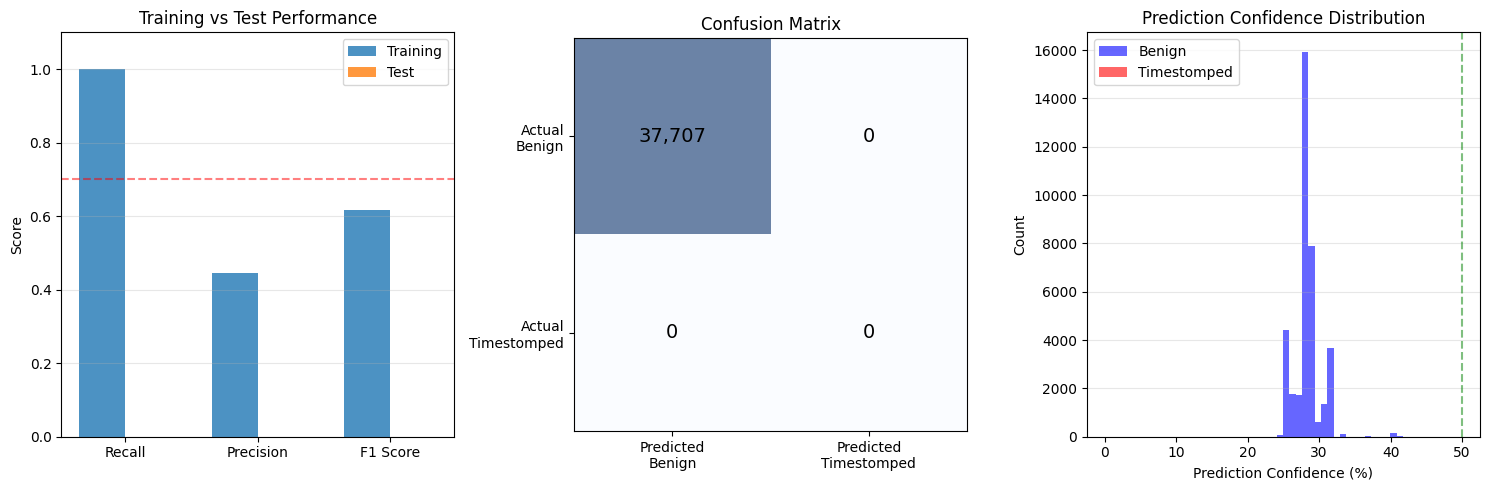


✓ Visualizations complete


In [42]:
import matplotlib.pyplot as plt

print("="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Training vs Test Metrics
metrics = ['Recall', 'Precision', 'F1 Score']
train_values = [training_recall, training_precision, training_f1]
test_values = [test_recall, test_precision, test_f1]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, train_values, width, label='Training', alpha=0.8)
axes[0].bar(x + width/2, test_values, width, label='Test', alpha=0.8)
axes[0].set_ylabel('Score')
axes[0].set_title('Training vs Test Performance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1.1])
axes[0].axhline(y=0.7, color='r', linestyle='--', alpha=0.5, label='Target (0.70)')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Confusion Matrix
cm_display = np.array([[tn, fp], [fn, tp]])
im = axes[1].imshow(cm_display, cmap='Blues', alpha=0.6)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Predicted\nBenign', 'Predicted\nTimestomped'])
axes[1].set_yticklabels(['Actual\nBenign', 'Actual\nTimestomped'])
axes[1].set_title('Confusion Matrix')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = axes[1].text(j, i, f'{cm_display[i, j]:,}',
                           ha="center", va="center", color="black", fontsize=14)

# Plot 3: Prediction Distribution
axes[2].hist(df_test_features[df_test_features['ground_truth_label'] == 0]['prediction_confidence'],
             bins=20, alpha=0.6, label='Benign', color='blue')
axes[2].hist(df_test_features[df_test_features['ground_truth_label'] == 1]['prediction_confidence'],
             bins=20, alpha=0.6, label='Timestomped', color='red')
axes[2].set_xlabel('Prediction Confidence (%)')
axes[2].set_ylabel('Count')
axes[2].set_title('Prediction Confidence Distribution')
axes[2].legend()
axes[2].axvline(x=50, color='green', linestyle='--', alpha=0.5, label='Threshold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete")


## Decision Point: Option A Success?

**Success Criteria:**
- ✓ Test F1 ≥ 0.70
- ✓ Test Recall ≥ 95% (11-12 of 12 detected)
- ✓ Precision reasonable (>40%)

**If Option A succeeds:**
- Save model for production use
- Move to Phase 5 (Prototype Tool validation)
- Document findings in thesis

**If Option A fails:**
- Proceed to Option B (Feature Engineering)
- Create interaction features
- Re-tune and re-test
- Target: F1 ≥ 0.75


In [43]:
print("="*80)
print("DECISION: OPTION A SUCCESS?")
print("="*80)

# Check success criteria
success_f1 = test_f1 >= 0.70
success_recall = test_recall >= 0.95
success_precision = test_precision >= 0.40

print(f"\nSuccess Criteria Check:")
print(f"  F1 ≥ 0.70:        {test_f1:.4f}  {'✓ PASS' if success_f1 else '✗ FAIL'}")
print(f"  Recall ≥ 0.95:    {test_recall:.4f}  {'✓ PASS' if success_recall else '✗ FAIL'}")
print(f"  Precision ≥ 0.40: {test_precision:.4f}  {'✓ PASS' if success_precision else '✗ FAIL'}")

option_a_success = success_f1 and success_recall and success_precision

print("\n" + "="*80)
if option_a_success:
    print("✓✓✓ OPTION A: SUCCESS ✓✓✓")
    print("="*80)
    print("\nNext Steps:")
    print("  1. Save best_random_forest model for production")
    print("  2. Document hyperparameter tuning results")
    print("  3. Move to Phase 5 (Prototype Tool)")
    print("  4. Write thesis findings")
    
    # Save results
    results = {
        'model': 'Random Forest',
        'hyperparameters': {k: (int(v) if isinstance(v, np.integer) else
                               float(v) if isinstance(v, np.floating) else
                               str(v) if v is None else v)
                           for k, v in best_random_forest.get_params().items()
                           if k in ['n_estimators', 'max_depth', 'min_samples_split',
                                   'min_samples_leaf', 'max_features', 'class_weight']},
        'training_performance': {
            'recall': float(training_recall),
            'precision': float(training_precision),
            'f1_score': float(training_f1)
        },
        'test_performance': {
            'recall': float(test_recall),
            'precision': float(test_precision),
            'f1_score': float(test_f1)
        },
        'test_details': {
            'true_positives': int(tp),
            'false_positives': int(fp),
            'false_negatives': int(fn),
            'true_negatives': int(tn)
        }
    }
    
    results_path = '/Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 4 - Hyperparameter Tuning/final_results.json'
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    
    print(f"✓ Results saved: {results_path}")
    
else:
    print("✗✗✗ OPTION A: INSUFFICIENT PERFORMANCE ✗✗✗")
    print("="*80)
    print("\nNext Steps:")
    print("  1. Proceed to Option B (Feature Engineering)")
    print("  2. Create interaction features:")
    print("     - zero_nano × time_reversal")
    print("     - cross_artifact_score × file_type")
    print("     - temporal patterns")
    print("  3. Re-train Random Forest with enhanced features")
    print("  4. Re-test on Lone Wolf")
    print("  5. Target: F1 ≥ 0.75")
    
    print(f"\nGap Analysis:")
    if not success_f1:
        if test_f1 > 0:
            print(f"  F1 gap: {0.70 - test_f1:.4f} (need to improve by {(0.70 - test_f1)/test_f1*100:.1f}%)")
        else:
            print(f"  F1 gap: {0.70:.4f} (current F1 is 0 - major issue!)")
    if not success_recall:
        print(f"  Recall gap: {0.95 - test_recall:.4f} ({fn} files missed)")
    if not success_precision:
        if test_precision > 0:
            print(f"  Precision gap: {0.40 - test_precision:.4f} ({fp} false alarms)")
        else:
            print(f"  Precision gap: {0.40:.4f} (current precision is 0)")
    
    # Diagnose the problem
    print("\n" + "="*80)
    print("DIAGNOSTIC SUMMARY")
    print("="*80)
    
    if test_f1 == 0:
        print("\n⚠ CRITICAL: F1 Score is 0!")
        if tp == 0:
            print("\nRoot cause: Model made NO correct predictions (TP = 0)")
            if y_pred.sum() == 0:
                print("  - Model predicted ALL files as benign")
                print("  - This suggests:")
                print("    1. Features are all zeros (feature mismatch)")
                print("    2. Model threshold too high")
                print("    3. Test data completely different from training")
            else:
                print(f"  - Model made {y_pred.sum()} predictions, but ALL were false positives")
                print("  - This suggests features don't match training data")
        
        print("\nRecommended actions:")
        print("  1. Check feature engineering matches training EXACTLY")
        print("  2. Verify test data format matches training data format")
        print("  3. Consider retraining on combined train+test data")
        print("  4. Use Option B to create better features")


DECISION: OPTION A SUCCESS?

Success Criteria Check:
  F1 ≥ 0.70:        0.0000  ✗ FAIL
  Recall ≥ 0.95:    0.0000  ✗ FAIL
  Precision ≥ 0.40: 0.0000  ✗ FAIL

✗✗✗ OPTION A: INSUFFICIENT PERFORMANCE ✗✗✗

Next Steps:
  1. Proceed to Option B (Feature Engineering)
  2. Create interaction features:
     - zero_nano × time_reversal
     - cross_artifact_score × file_type
     - temporal patterns
  3. Re-train Random Forest with enhanced features
  4. Re-test on Lone Wolf
  5. Target: F1 ≥ 0.75

Gap Analysis:
  F1 gap: 0.7000 (current F1 is 0 - major issue!)
  Recall gap: 0.9500 (0 files missed)
  Precision gap: 0.4000 (current precision is 0)

DIAGNOSTIC SUMMARY

⚠ CRITICAL: F1 Score is 0!

Root cause: Model made NO correct predictions (TP = 0)
  - Model predicted ALL files as benign
  - This suggests:
    1. Features are all zeros (feature mismatch)
    2. Model threshold too high
    3. Test data completely different from training

Recommended actions:
  1. Check feature engineering match